# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [17]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [18]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

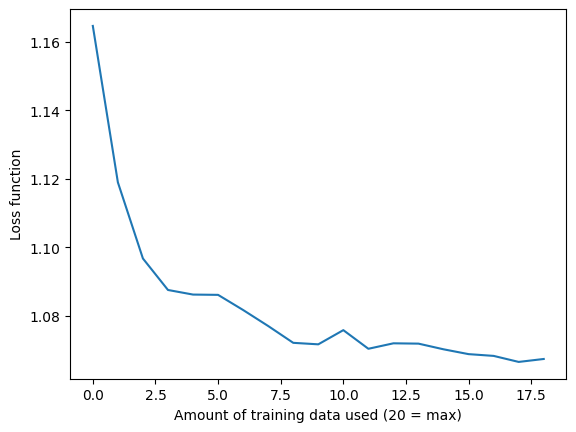

In [19]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [20]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

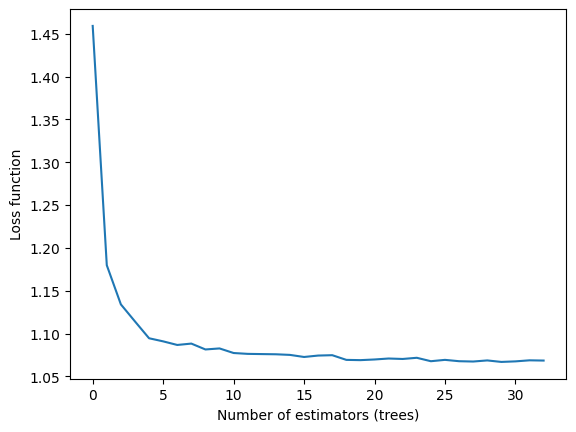

In [21]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [24]:
# # ==========================================================
# #  Cribo all‑in‑one EDA + Random‑Forest pipeline
# # ==========================================================
# # → pip install kagglehub pandas numpy matplotlib seaborn scikit-learn

# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OrdinalEncoder, StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# from sklearn.model_selection import (
#     RandomizedSearchCV, RepeatedKFold, RepeatedStratifiedKFold,
#     train_test_split
# )
# from sklearn.metrics import (
#     accuracy_score, f1_score, confusion_matrix,
#     r2_score, mean_absolute_error
# )
# from sklearn.linear_model import LinearRegression

# import kagglehub

# sns.set_style("whitegrid")
# RANDOM_STATE = 42

# # ----------------------------------------------------------
# # 1. LOAD DATA
# # ----------------------------------------------------------
# cribo_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
# dfs = [
#     pd.read_csv(Path(root) / f)
#     for root, _, files in os.walk(cribo_path)
#     for f in files if f.lower().endswith(".csv")
# ]
# cribo = pd.concat(dfs, ignore_index=True)
# print(f"Loaded {len(cribo):,} rows × {cribo.shape[1]} columns")

# # ----------------------------------------------------------
# # 2. BASIC CLEANING & FEATURE ENGINEERING
# # ----------------------------------------------------------
# num_cols = cribo.select_dtypes(include=[np.number]).columns
# cat_cols = cribo.select_dtypes(include=["object", "category"]).columns

# cribo[num_cols] = SimpleImputer(strategy="median").fit_transform(cribo[num_cols])
# cribo[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(cribo[cat_cols])
# cribo[cat_cols] = OrdinalEncoder(
#     handle_unknown="use_encoded_value", unknown_value=-1
# ).fit_transform(cribo[cat_cols])

# # engineered flags
# cribo["is_well_known_dest"] = (cribo["Destination Port"] < 1024).astype(int)
# cribo["is_ephemeral_src"]   = (cribo["Source Port"]   > 49152).astype(int)
# cribo["dest_bucket"] = pd.cut(
#     cribo["Destination Port"], bins=[0, 1024, 49152, 65536], labels=[1, 2, 3]
# ).astype(int)

# # ----------------------------------------------------------
# # 3. CORRELATION ANALYSIS
# # ----------------------------------------------------------
# data_num   = cribo.select_dtypes(include=[np.number])
# nunique_ok = data_num.nunique() > 1
# corr       = data_num.loc[:, nunique_ok].corr(method="spearman")

# corr_pairs = (
#     corr.where(~np.eye(corr.shape[0], dtype=bool))
#          .unstack().dropna().abs()
#          .sort_values(ascending=False)
# )
# print("\n=== Top‑15 absolute Spearman correlations ===")
# for (a, b), val in corr_pairs.head(15).items():
#     print(f"{a:<25} ↔ {b:<25}  ρ = {val:.3f}")

# top_feats = pd.unique([i for i, _ in corr_pairs.head(20).index])
# corr_zoom = corr.loc[top_feats, top_feats]
# plt.figure(figsize=(0.6*len(top_feats), 6))
# sns.heatmap(corr_zoom, cmap="coolwarm", center=0, annot=True, fmt=".2f",
#             square=True, linewidths=.4, cbar_kws={"shrink": .8})
# plt.title("Zoom – Top‑correlated numeric features")
# plt.tight_layout(); plt.show()

# # ----------------------------------------------------------
# # 4. PORT‑FOCUSED BUBBLE / HEXBIN PLOT
# # ----------------------------------------------------------
# top_dest_ports = cribo["Destination Port"].value_counts().head(20).index
# focus = cribo[cribo["Destination Port"].isin(top_dest_ports)]

# if len(focus):
#     focus = focus.sample(n=min(6000, len(focus)), random_state=RANDOM_STATE)
#     plt.figure(figsize=(9, 7))
#     sc = plt.scatter(focus["Destination Port"], focus["Source Port"],
#                      c=focus["Anomaly Scores"] if "Anomaly Scores" in focus else None,
#                      cmap="coolwarm", s=40, alpha=0.65,
#                      edgecolor="k", linewidth=0.25)
#     if "Anomaly Scores" in focus:
#         plt.colorbar(sc, label="Anomaly Score")
#     plt.xscale("log"); plt.yscale("log")
#     plt.xlabel("Destination Port (log)"); plt.ylabel("Source Port (log)")
#     plt.title("Top‑20 destination ports")
#     plt.tight_layout(); plt.show()
# else:
#     sample = cribo.sample(n=min(6000, len(cribo)), random_state=RANDOM_STATE)
#     plt.figure(figsize=(8,6))
#     hb = plt.hexbin(sample["Destination Port"], sample["Source Port"],
#                     gridsize=60, cmap="magma", mincnt=1)
#     plt.colorbar(hb, label="Hit count")
#     plt.xscale("log"); plt.yscale("log")
#     plt.xlabel("Destination Port (log)"); plt.ylabel("Source Port (log)")
#     plt.title("Port‑to‑Port density – hexbin fallback")
#     plt.tight_layout(); plt.show()

# # ----------------------------------------------------------
# # 5. PCA (SCALED VS RAW)
# # ----------------------------------------------------------
# num_cols = cribo.select_dtypes(include=[np.number]).columns
# X_scaled = StandardScaler().fit_transform(cribo[num_cols])

# pca_scaled = PCA().fit(X_scaled)
# evr_scaled = pca_scaled.explained_variance_ratio_

# plt.figure(figsize=(8,5))
# plt.bar(np.arange(1, len(evr_scaled)+1), evr_scaled*100, width=0.6)
# plt.xticks(np.arange(1, len(evr_scaled)+1))
# plt.title("PCA Scree Plot – Scaled features")
# plt.xlabel("Principal Component"); plt.ylabel("Variance Explained (%)")
# plt.tight_layout(); plt.show()

# pc1_scores = pca_scaled.transform(X_scaled)[:, 0]
# plt.figure(figsize=(8,4))
# sns.histplot(pc1_scores, bins=40, kde=True)
# plt.title(f"PC1 score distribution ({evr_scaled[0]*100:.1f}% variance)")
# plt.xlabel("PC1 score"); plt.tight_layout(); plt.show()

# # raw for comparison
# X_raw = cribo[num_cols].values
# evr_raw = PCA().fit(X_raw).explained_variance_ratio_

# plt.figure(figsize=(8,5))
# plt.bar(np.arange(1, len(evr_raw)+1), evr_raw*100, width=0.6, color="tab:orange")
# plt.xticks(np.arange(1, len(evr_raw)+1))
# plt.title("PCA Scree Plot – Raw (un‑scaled)")
# plt.xlabel("Principal Component"); plt.ylabel("Variance Explained (%)")
# plt.tight_layout(); plt.show()

# # ----------------------------------------------------------
# # 6. RANDOM‑FOREST WITH CV + HOLD‑OUT TEST
# # ----------------------------------------------------------
# TARGET_COL = "Severity Level"   # ← set this to the column you want to predict

# if TARGET_COL not in cribo.columns:
#     raise ValueError(f"'{TARGET_COL}' not found in dataframe.")

# y = cribo[TARGET_COL]
# X = cribo.drop(columns=[TARGET_COL])

# is_regression = pd.api.types.is_numeric_dtype(y) and y.nunique() > 10

# Model = RandomForestRegressor if is_regression else RandomForestClassifier
# cv = (RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE) if is_regression
#       else RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE))
# scorer = "neg_mean_absolute_error" if is_regression else "f1"

# param_dist = {
#     "n_estimators":      np.arange(200, 2001, 200),
#     "max_depth":         [None] + list(np.arange(4, 41, 4)),
#     "min_samples_split": np.arange(2, 11),
#     "min_samples_leaf":  np.arange(1, 11),
#     "max_features":      ["sqrt", "log2", 0.3, 0.5, None],
#     "bootstrap":         [True, False],
# }

# rf_base = Model(random_state=RANDOM_STATE, n_jobs=-1)
# search = RandomizedSearchCV(
#     rf_base, param_distributions=param_dist,
#     n_iter=60, scoring=scorer, cv=cv, n_jobs=-1,
#     verbose=1, random_state=RANDOM_STATE
# )
# search = RandomizedSearchCV(
#     rf_base,
#     param_distributions=param_dist,
#     n_iter=60,
#     scoring="neg_mean_absolute_error" if is_regression else "f1",
#     cv=(RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
#         if is_regression else
#         RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)),
#     n_jobs=-1,               # ←------------- parallel CV search
#     verbose=1,
#     random_state=RANDOM_STATE,
# )
# search.fit(X, y)
# print("\nBest CV score:", search.best_score_)
# print("Best params:", search.best_params_)

# best_rf = search.best_estimator_

# # hold‑out test
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20,
#     stratify=None if is_regression else y,
#     random_state=RANDOM_STATE
# )
# best_rf.fit(X_train, y_train)
# y_pred = best_rf.predict(X_test)

# if is_regression:
#     mae = mean_absolute_error(y_test, y_pred)
#     r2  = r2_score(y_test, y_pred)
#     print(f"Hold‑out MAE = {mae:,.3f}")
#     print(f"Hold‑out R²  = {r2:,.3f}")
# else:
#     acc = accuracy_score(y_test, y_pred)
#     f1  = f1_score(y_test, y_pred, average="weighted")
#     print(f"Hold‑out accuracy = {acc:.3f}")
#     print(f"Hold‑out F1‑score = {f1:.3f}")
#     # confusion matrix
#     cm = confusion_matrix(y_test, y_pred)
#     plt.figure(figsize=(6,5))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
#     plt.title("Confusion matrix – hold‑out set")
#     plt.xlabel("Predicted"); plt.ylabel("True")
#     plt.tight_layout(); plt.show()

# # feature importances
# importances = pd.Series(best_rf.feature_importances_, index=X.columns)
# top_imp = importances.nlargest(15)
# plt.figure(figsize=(7,5))
# top_imp.sort_values().plot.barh()
# plt.title("Top 15 feature importances (Random Forest)")
# plt.tight_layout(); plt.show()

# # ----------------------------------------------------------
# print("\nPipeline complete ✔")
# print(f"PCA: first 2 PCs capture {(evr_scaled[:2].sum()*100):.1f}% of scaled variance")
# # ==========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
cribo = pd.read_excel("cribo_clean.xlsx")  # Replace with your path

# 2. Drop high-cardinality / text-heavy columns
columns_to_drop = [
    "Timestamp", "Source IP Address", "Destination IP Address",
    "Payload Data", "Attack Signature", "User Information",
    "Device Information", "Geo-location Data", "Proxy Information"
]
cribo_cleaned = cribo.drop(columns=columns_to_drop, errors='ignore')

# 3. Encode and impute
cat_cols = cribo_cleaned.select_dtypes(include='object').columns
num_cols = cribo_cleaned.select_dtypes(include=[np.number]).columns

cribo_cleaned[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(cribo_cleaned[cat_cols])
cribo_cleaned[num_cols] = SimpleImputer(strategy='median').fit_transform(cribo_cleaned[num_cols])
cribo_cleaned[cat_cols] = OrdinalEncoder().fit_transform(cribo_cleaned[cat_cols])

# 4. Create binary target based on Anomaly Scores
cribo_cleaned['target'] = (cribo_cleaned['Anomaly Scores'] > cribo_cleaned['Anomaly Scores'].median()).astype(int)

# 5. Features and labels
X = cribo_cleaned.drop(columns=['target', 'Anomaly Scores'])
y = cribo_cleaned['target']

# 6. Subsample to ~12,000 rows for safe cross-validation
X_subsampled, _, y_subsampled, _ = train_test_split(
    X, y, train_size=30000, stratify=y, random_state=42
)

# 7. Define the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1  # Avoid memory overload
)

# 8. Run 3-fold CV with timing
start = time.time()
cv_scores = cross_val_score(rf_model, X_subsampled, y_subsampled, cv=3, scoring='accuracy', n_jobs=1)
end = time.time()

# 9. Print results
print("=== Cross-Validation Results on 12,000 Row Subsample ===")
print(f"Fold Accuracies: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Elapsed Time: {end - start:.2f} seconds")




=== Cross-Validation Results on 12,000 Row Subsample ===
Fold Accuracies: [0.5042 0.4973 0.4984]
Mean Accuracy: 0.5000
Elapsed Time: 1.79 seconds


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

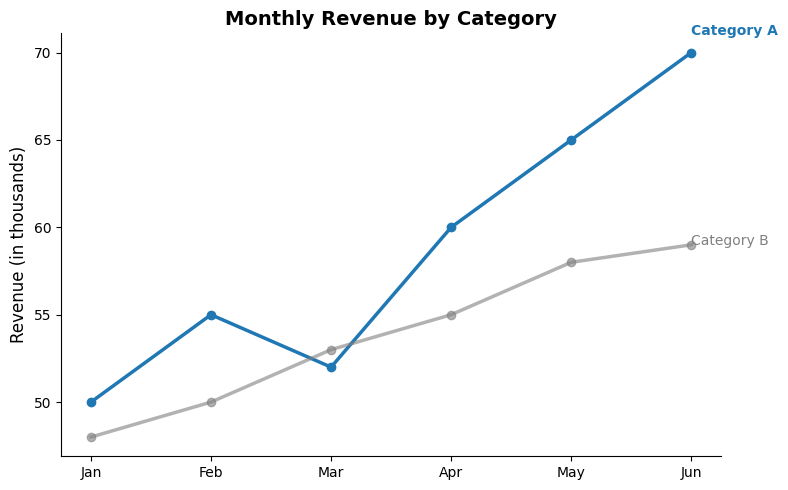

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample line chart data: Monthly revenue for two categories
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
category_a = [50, 55, 52, 60, 65, 70]
category_b = [48, 50, 53, 55, 58, 59]

# Create DataFrame
df = pd.DataFrame({
    'Month': months,
    'Category A': category_a,
    'Category B': category_b
})

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the two lines
ax.plot(df['Month'], df['Category A'], label='Category A', color='#1f77b4', linewidth=2.5, marker='o')
ax.plot(df['Month'], df['Category B'], label='Category B', color='gray', linewidth=2.5, marker='o', alpha=0.6)

# Annotate the last points directly
ax.text(len(months)-1, category_a[-1] + 1, 'Category A',
        color='#1f77b4', fontsize=10, weight='bold', ha='left')
ax.text(len(months)-1, category_b[-1], 'Category B',
        color='gray', fontsize=10, ha='left')

# Add title and y-axis label
ax.set_title("Monthly Revenue by Category", fontsize=14, weight='bold')
ax.set_ylabel("Revenue (in thousands)", fontsize=12)

# Simplify the axes for a cleaner visual
ax.set_xlabel("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', which='major', labelsize=10)

# Hide the legend since we're labeling directly
ax.legend().set_visible(False)

plt.tight_layout()
plt.show()
